In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import json
from scipy.stats import bootstrap

In [2]:
import decision_infovalue

# Data Preparation

In [3]:
data, metadata = decision_infovalue.get_dataset("cxr")

# Information Model

In [91]:
info_model = decision_infovalue.DecisionInfoModel(data, metadata["target_name"], 
                                     signals=["diagnosis","densenet121_pred","inception_v3_pred","swin_b_pred","resnet50_pred","vit_b_16_pred"], 
                                     scoring_rule="brier",
                                     binning_method=None,
                                     fit_test_ratio=0.8,
                                     overfit_tolerance=0.1)

In [92]:
info_model.all_breaks

{'diagnosis': None,
 'densenet121_pred': None,
 'inception_v3_pred': None,
 'swin_b_pred': None,
 'resnet50_pred': None,
 'vit_b_16_pred': None}

# Global human-complementary information value in each AI model

In [89]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches


def categorical_kde_plot(
    df,
    variable,
    category,
    category_order=None,
    color=None,
    horizontal=False,
    rug=True,
    figsize=None,
):
    """Draw a categorical KDE plot

    Parameters
    ----------
    df: pd.DataFrame
        The data to plot
    variable: str
        The column in the `df` to plot (continuous variable)
    category: str
        The column in the `df` to use for grouping (categorical variable)
    color: str or None
        The column in the `df` to use for color
    horizontal: bool
        If True, draw density plots horizontally. Otherwise, draw them
        vertically.
    rug: bool
        If True, add also a sns.rugplot.
    figsize: tuple or None
        If None, use default figsize of (7, 1*len(categories))
        If tuple, use that figsize. Given to plt.subplots as an argument.
    """
    if category_order is None:
        categories = list(df[category].unique())
    else:
        categories = category_order[:]

    figsize = (7, 1.0 * len(categories))

    fig, axes = plt.subplots(
        nrows=len(categories) if horizontal else 1,
        ncols=1 if horizontal else len(categories),
        figsize=figsize[::-1] if not horizontal else figsize,
        sharex=horizontal,
        sharey=not horizontal,
    )

    palette = {'Human': '#7570B3', 'AI': '#D95F02', 'Human + AI': '#1B9E77'}

    for i, (cat, ax) in enumerate(zip(categories, axes)):
        color_encoder = list(dict.fromkeys(df[df[category] == cat][color]))
        loc_palette = [palette[c] for c in color_encoder]

        sns.kdeplot(
            data=df[df[category] == cat],
            x=variable if horizontal else None,
            y=None if horizontal else variable,
            # kde kwargs
            bw_adjust=0.5,
            clip_on=False,
            fill=True,
            alpha=1,
            linewidth=0,
            ax=ax,
            hue=color,
            palette=loc_palette,
            legend=False,
        )
        ax.set_xlim(0, full_info_xgb - no_info_xgb)

        keep_variable_axis = (i == len(fig.axes) - 1) if horizontal else (i == 0)

        if rug:
            sns.rugplot(
                data=df[df[category] == cat],
                x=variable if horizontal else None,
                y=None if horizontal else variable,
                ax=ax,
                color="black",
                height=0.025 if keep_variable_axis else 0.04,
            )

        _format_axis(
            ax,
            cat,
            horizontal,
            keep_variable_axis=keep_variable_axis,
        )

    # Add legend to the last axis
    if len(axes) > 0:
        last_ax = axes[-1]
        last_ax.legend(handles=[mpatches.Patch(color='#D95F02', label='AI decisions'),
        mpatches.Patch(color='#7570B3', label='Human decisions'),
        mpatches.Patch(color='#1B9E77', label='Human-AI team decisions')], loc=(0.3,7))
    plt.tight_layout()
    plt.show()


def _format_axis(ax, category, horizontal=False, keep_variable_axis=True):

    # Remove the axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if horizontal:
        ax.set_ylabel(None)
        lim = ax.get_ylim()
        ax.set_yticks([(lim[0] + lim[1]) / 2])
        ax.set_yticklabels([category])
        if not keep_variable_axis:
            ax.get_xaxis().set_visible(False)
            ax.spines["bottom"].set_visible(False)
    else:
        ax.set_xlabel(None)
        lim = ax.get_xlim()
        ax.set_xticks([(lim[0] + lim[1]) / 2])
        ax.set_xticklabels([category])
        if not keep_variable_axis:
            ax.get_yaxis().set_visible(False)
            ax.spines["left"].set_visible(False)

In [93]:
# Prepare data for KDE plot
models = ["vit_b_16_pred", "densenet121_pred", "inception_v3_pred", "swin_b_pred", "resnet50_pred", np.nan]

kde_data = []
for model in models:
    for with_human in [True, False]:
        if not with_human and type(model) != str:
            continue
        signals = [model] if not with_human else ([model, "diagnosis"] if not type(model) == float else ["diagnosis"])
        kde_data.append({
            'model': model,
            "with_human": with_human,
            'complement_info_value': bootstrap((info_model.complement_info_value(signals, [], ret_orig_value=True),), statistic=np.mean).bootstrap_distribution
        })



kde_df = pd.DataFrame(kde_data).explode(column="complement_info_value").reset_index(drop=True)
kde_df["complement_info_value"] = kde_df["complement_info_value"].astype(float)


In [94]:
kde_df.loc[:, "color_encoder"] = kde_df[["model", "with_human"]].apply(lambda x: "Human + AI" if type(x[0]) == str and x[1] else "AI" if type(x[0]) == str and not x[1] else "Human", axis=1)

/var/folders/3h/9bh8gjqn3r99nq3frnmlnkhr0000gn/T/ipykernel_90051/490538471.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  kde_df.loc[:, "color_encoder"] = kde_df[["model", "with_human"]].apply(lambda x: "Human + AI" if type(x[0]) == str and x[1] else "AI" if type(x[0]) == str and not x[1] else "Human", axis=1)


In [95]:
kde_df.loc[:, "model"] = kde_df["model"].fillna("Human")

In [87]:
kde_df

,model,with_human,complement_info_value,color_encoder
0,vit_b_16_pred,True,0.055658,Human + AI
1,vit_b_16_pred,True,0.052840,Human + AI
2,vit_b_16_pred,True,0.054263,Human + AI
3,vit_b_16_pred,True,0.056764,Human + AI
4,vit_b_16_pred,True,0.055416,Human + AI
...,...,...,...,...
109984,Human,True,0.030371,Human
109985,Human,True,0.029375,Human
109986,Human,True,0.028028,Human
109987,Human,True,0.028060,Human


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option

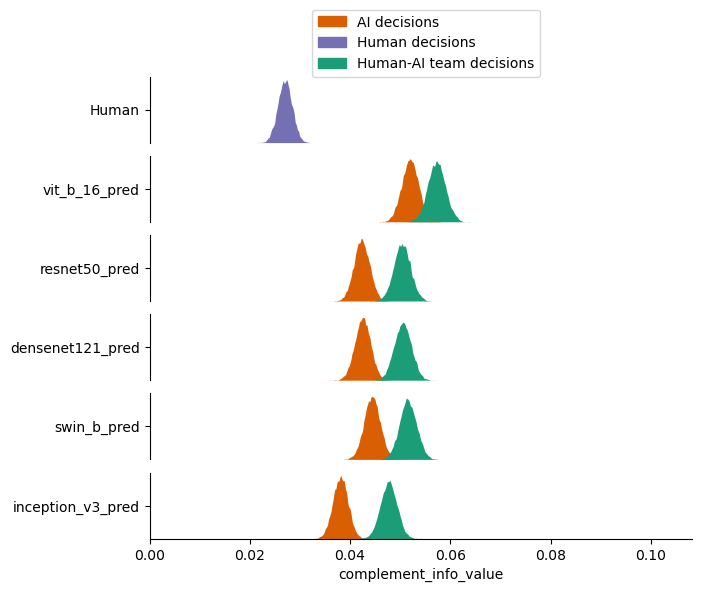

In [96]:

# Create KDE plot
# plt.figure(figsize=(12, 8))
# sns.catplot(data=kde_df, y='feature', x='complement_info_value', hue='agent_decision', 
#                palette=['#D95F02', '#7570B3', '#1B9E77'], kind="violin", dodge=False, linewidth=0)
categorical_kde_plot(
    kde_df,
    variable="complement_info_value",
    category="model",
    color="color_encoder",
    category_order=[ "Human", "vit_b_16_pred","resnet50_pred",  "densenet121_pred", "swin_b_pred", "inception_v3_pred"],
    horizontal=True,
    rug=False
)

# Robust analysis on a grid of V-shaped scoring rules

In [12]:
grid_size = 100
model_pair_diffs = np.zeros((len(models), len(models), grid_size))
model_pair_kinks = np.zeros((len(models), len(models), grid_size))
models = [ "vit_b_16_pred", "resnet50_pred",  "densenet121_pred", "swin_b_pred", "inception_v3_pred"]
for model in models:
    for compare_model in models:
        model_pair_diffs[models.index(model), models.index(compare_model)], \
        model_pair_kinks[models.index(model), models.index(compare_model)] = \
            info_model.robust_analysis_on_v_shaped_scoring_rule(model, compare_model, 
                                                                base_signals=["diagnosis"], 
                                                                ret_diff=True, grid_size=grid_size)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/3h/9bh8gjqn3r99nq3frnmlnkhr0000gn/T/ipykernel_90051/794466898.py:25: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0, hspace=0)


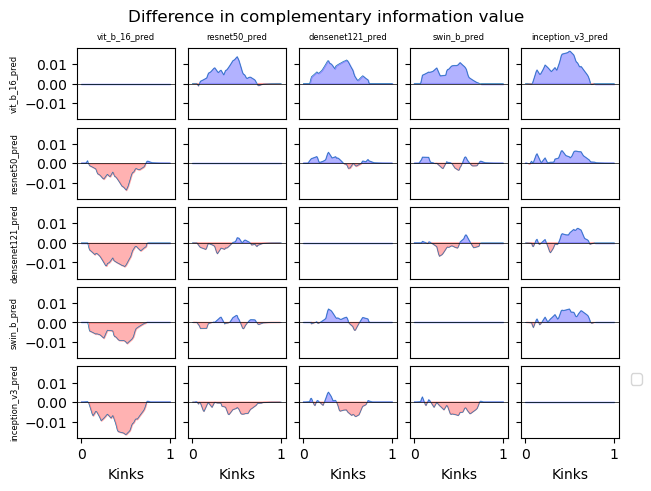

In [13]:

# plt.figure(figsize=(10, 6))
fig, axes = plt.subplots(len(models), len(models), layout='constrained', sharey=True)

for i, model in enumerate(models):
    for j, compare_model in enumerate(models):
        axes[i, j].plot(model_pair_kinks[i,j], model_pair_diffs[i,j], linewidth=0.5)
        axes[i, j].fill_between(model_pair_kinks[i,j], model_pair_diffs[i,j], 0, 
                               where=(model_pair_diffs[i,j] >= 0), color='blue', alpha=0.3)
        axes[i, j].fill_between(model_pair_kinks[i,j], model_pair_diffs[i,j], 0, 
                               where=(model_pair_diffs[i,j] < 0), color='red', alpha=0.3)
        axes[i, j].axhline(y=0, color='black', alpha=1, linewidth=0.5)
        if i == len(models) - 1:
            axes[i, j].set_xlabel('Kinks')
        if i == 0:
            axes[i, j].set_title(f'{compare_model}', fontsize=6)
        if i != len(models) - 1:
            axes[i, j].set_xticks([])
        if j == 0:
            axes[i, j].set_ylabel(f'{model}', fontsize=6)

# plt.xlabel('Kink position')
# plt.ylabel('Difference in complementary information value')
plt.suptitle('Difference in complementary information value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(wspace=0, hspace=0)